In [2]:
import os
import ast
import math
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [1]:
CSV_PATH = "data/ARP_dataset_fixed_Sentiment.csv"

In [ ]:
import ast
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

TOP_N = 50  

# (sentence "[('Inflation', 0.66), ('Employment', -0.33)]"）
def parse_entities(cell):
    try:
        items = ast.literal_eval(cell) if isinstance(cell, str) else []
        out = []
        for it in items:
            if isinstance(it, (tuple, list)) and len(it) >= 2:
                name, score = it[0], it[1]
                if isinstance(name, str) and name.strip():
                    try:
                        float(score)  
                        out.append((name.strip(), float(score)))
                    except Exception:
                        pass
        return out
    except Exception:
        return []

df = pd.read_csv(CSV_PATH)
parsed = df["Entities"].apply(parse_entities)


all_entities = [name for pairs in parsed for (name, _) in pairs]
freq = Counter(all_entities)
freq_df = pd.DataFrame(freq.most_common(), columns=["Entity", "Count"])



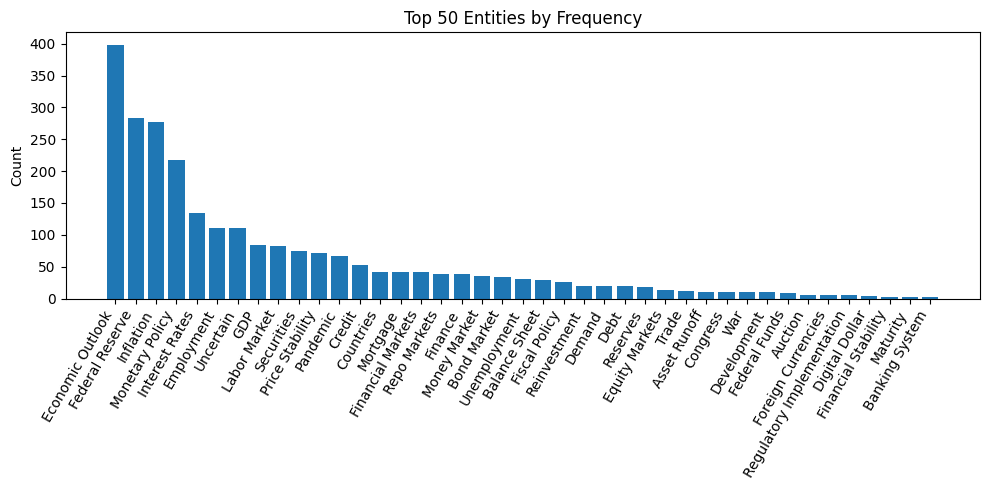

In [ ]:
# Top-N 
top_df = freq_df.head(TOP_N)
plt.figure(figsize=(10, 5))
plt.bar(top_df["Entity"], top_df["Count"])
plt.title(f"Top {TOP_N} Entities by Frequency")
plt.ylabel("Count")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()


In [ ]:


def parse_scores(cell):
    try:
        items = ast.literal_eval(cell) if isinstance(cell, str) else []
        out = []
        for it in items:
            if isinstance(it, (tuple, list)) and len(it) >= 2:
                name, score = it[0], it[1]
                if isinstance(name, str) and name.strip():
                    try:
                        out.append(float(score))
                    except Exception:
                        pass
        return out
    except Exception:
        return []

def coarse_label(x: float) -> str:
    if x > 1e-9:
        return "Positive"
    elif x < -1e-9:
        return "Negative"
    return "Neutral"

df = pd.read_csv(CSV_PATH)
scores_nested = df["Entities"].apply(parse_scores)
scores = [s for row in scores_nested for s in row]

coarse = pd.Series([coarse_label(v) for v in scores])
order = ["Negative", "Neutral", "Positive"]
coarse_counts = coarse.value_counts().reindex(order).fillna(0).astype(int)


coarse_df = pd.DataFrame({"Category": coarse_counts.index, "Count": coarse_counts.values})
coarse_df


,Category,Count
0,Negative,661
1,Neutral,540
2,Positive,1297


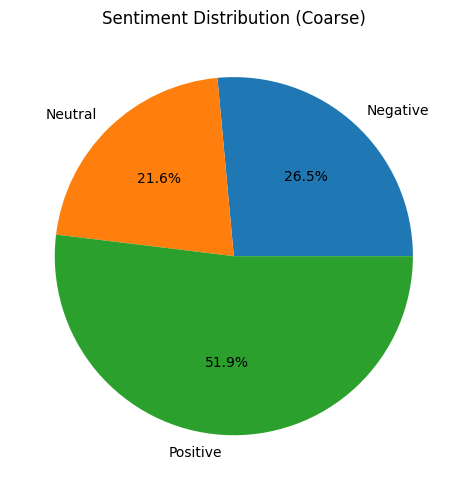

In [ ]:
# plot
plt.figure(figsize=(5, 5))
plt.pie(coarse_counts.values, labels=coarse_counts.index, autopct="%1.1f%%")
plt.title("Sentiment Distribution (Coarse)")
plt.tight_layout()
plt.show()


In [ ]:

CANONICAL_BINS = [-1.0, -0.66, -0.33, 0.0, 0.33, 0.66, 1.0]
BIN_LABELS     = ["-1.00","-0.66","-0.33","0.00","0.33","0.66","1.00"]
SNAP_TOL       = 0.05  

def parse_scores(cell):
    try:
        items = ast.literal_eval(cell) if isinstance(cell, str) else []
        out = []
        for it in items:
            if isinstance(it, (tuple, list)) and len(it) >= 2:
                name, score = it[0], it[1]
                if isinstance(name, str) and name.strip():
                    try:
                        out.append(float(score))
                    except Exception:
                        pass
        return out
    except Exception:
        return []

def snap_to_bin(x: float, bins=CANONICAL_BINS, tol=SNAP_TOL):
    best = min(bins, key=lambda b: abs(b - x))
    return best if abs(best - x) <= tol else round(x, 2)

df = pd.read_csv(CSV_PATH)
scores_nested = df["Entities"].apply(parse_scores)
scores = [s for row in scores_nested for s in row]

snapped = [snap_to_bin(v) for v in scores]
cnt = Counter(snapped)

bin_df = pd.DataFrame({
    "Bin": BIN_LABELS,
    "Count": [cnt.get(b, 0) for b in CANONICAL_BINS]
})
bin_df


,Bin,Count
0,-1.00,39
1,-0.66,282
2,-0.33,340
3,0.00,540
4,0.33,691
5,0.66,496
6,1.00,110


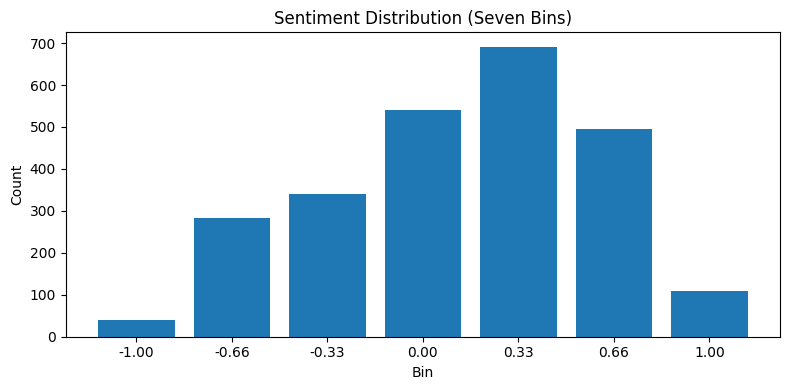

In [ ]:
# plot
plt.figure(figsize=(8, 4))
plt.bar(bin_df["Bin"], bin_df["Count"])
plt.title("Sentiment Distribution (Seven Bins)")
plt.xlabel("Bin")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


In [ ]:


def parse_scores(cell):
    try:
        items = ast.literal_eval(cell) if isinstance(cell, str) else []
        return [float(s[1]) for s in items if isinstance(s, (list,tuple)) and len(s)>=2]
    except Exception:
        return []

df = pd.read_csv(CSV_PATH)
scores_nested = df["Entities"].apply(parse_scores)
scores = pd.Series([x for row in scores_nested for x in row], name="score")

desc = pd.DataFrame({
    "n":[scores.size],
    "mean":[scores.mean()],
    "sd":[scores.std(ddof=1)],
    "median":[scores.median()],
    "p25":[scores.quantile(0.25)],
    "p75":[scores.quantile(0.75)],
    "skew":[scores.skew()],
    "kurt":[scores.kurt()]  # Fisher 
})
desc.round(3)


,n,mean,sd,median,p25,p75,skew,kurt
0,2498,0.131,0.472,0.33,-0.33,0.33,-0.304,-0.645
